# Section 1.2.4 — Deuxième modélisation : files Hawkes couplées

Les ajouts restent au taux constant
$\mu^+$, tandis que les retraits ont une intensité de Hawkes exponentielle :

$$
\lambda^-(t)
=\mu^- -\int_0^t \alpha e^{-\beta(t-s)}\,dN_s^+
+\int_0^t \alpha e^{-\beta(t-s)}\,dN_s^- .
$$

L'interprétation est la suivante :

- un ajout augmente la taille de la file et **diminue** temporairement le taux
  de retrait futur ;
- un retrait signale une consommation en cours et **augmente** temporairement
  le taux de retrait futur.

Tout le notebook est écrit avec cette convention. Les anciennes conventions de
signes ne sont pas utilisées ici.


In [1]:
import sys
sys.path.insert(0, '.')

import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.hawkes import (
    simulate_hawkes_queue,
    simulate_coupled_hawkes,
    hawkes_stationary_intensity,
)
from model.hitting_times import simulate_until_hit_zero

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
MU_PLUS = 1.2
MU_MINUS = 1.5
ALPHA = 0.3
BETA = 0.5
RATIO = ALPHA / BETA
Q0 = 10

print(f"Paramètres : μ⁺={MU_PLUS}, μ⁻={MU_MINUS}, α={ALPHA}, β={BETA}, α/β={RATIO:.2f}")
print("Signature simulate_hawkes_queue :", inspect.signature(simulate_hawkes_queue))
print("Signature simulate_coupled_hawkes :", inspect.signature(simulate_coupled_hawkes))


Paramètres : μ⁺=1.2, μ⁻=1.5, α=0.3, β=0.5, α/β=0.60
Signature simulate_hawkes_queue : (q_init: int = 10, mu_plus: float = 1.2, mu_minus: float = 1.5, alpha: float = 0.3, beta: float = 0.5, T_max: float = 1000.0, rng: Optional[numpy.random._generator.Generator] = None, stop_at_zero: bool = True, sign_convention: str = 'v4') -> model.hawkes.HawkesQueueResult
Signature simulate_coupled_hawkes : (q1_init: int = 10, q_neg1_init: int = 10, mu_plus: float = 1.2, mu_minus: float = 1.5, alpha: float = 0.3, beta: float = 0.5, T_max: float = 1000.0, rng: Optional[numpy.random._generator.Generator] = None, stop_at_zero: bool = True, sign_convention: str = 'v4') -> model.hawkes.CoupledHawkesResult


## Vérification des signes et implémentation itérative

On pose

$$
H(t)=
-\sum_{s<t,\ \Delta N_s^+=1}\alpha e^{-\beta(t-s)}
+\sum_{s<t,\ \Delta N_s^-=1}\alpha e^{-\beta(t-s)},
\qquad
\lambda^-(t)=\mu^-+H(t).
$$

Entre deux événements $t_k$ et $t_{k+1}=t_k+\delta t_k$,

$$
H(t_{k+1}^-)=H(t_k^+)e^{-\beta\delta t_k}.
$$

Au saut $t_{k+1}$, on met ensuite à jour

$$
H(t_{k+1}^+)=
\begin{cases}
H(t_{k+1}^-)-\alpha, & \text{ajout},\\
H(t_{k+1}^-)+\alpha, & \text{retrait}.
\end{cases}
$$

C'est exactement la logique utilisée par l'algorithme d'Ogata : on fait
décroître l'état $H$, on accepte ou rejette un candidat par thinning, puis
on applique le saut $\pm\alpha$.


In [2]:
m_theo_v4 = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, "v4")
print(f"Moyenne stationnaire théorique v4 : m⁻ = {m_theo_v4:.4f}")
print(f"Drift effectif sans bord : μ⁺ - m⁻ = {MU_PLUS - m_theo_v4:.4f}")

source = inspect.getsource(simulate_hawkes_queue)
checks = {
    "ajout v4 : H -= α": 'add_jump = -alpha if convention == "v4" else alpha' in source,
    "retrait v4 : H += α": 'remove_jump = alpha if convention == "v4" else -alpha' in source,
}
for nom, ok in checks.items():
    print(f"{nom:22s} -> {'OK' if ok else 'à vérifier'}")


Moyenne stationnaire théorique v4 : m⁻ = 1.9500
Drift effectif sans bord : μ⁺ - m⁻ = -0.7500
ajout v4 : H -= α      -> OK
retrait v4 : H += α    -> OK


## Condition de stationnarité — preuve v4

On note

$$
r=\int_0^\infty \alpha e^{-\beta u}\,du=\frac{\alpha}{\beta}.
$$

Dans la convention v4,

$$
\lambda^-(t)=\mu^- - \phi \ast dN^+(t) + \phi \ast dN^-(t).
$$

En régime stationnaire, si
$m^- = \mathbb{E}[\lambda^-(t)]$, alors

$$
\frac{\mathbb{E}[dN_t^+]}{dt}=\mu^+,
\qquad
\frac{\mathbb{E}[dN_t^-]}{dt}=m^-.
$$

En prenant l'espérance dans l'équation de l'intensité, on obtient

$$
m^- = \mu^- - r\mu^+ + r m^-.
$$

Donc

$$
(1-r)m^- = \mu^- - r\mu^+,
\qquad
m^- = \frac{\mu^- - r\mu^+}{1-r}.
$$

Avec les paramètres de référence,

$$
r=\frac{0.3}{0.5}=0.6,
\qquad
m^- = \frac{1.5-0.6\times1.2}{1-0.6}=1.95.
$$

La condition de stabilité est $r<1$. Elle correspond au fait que la masse
$L^1$ du noyau excitateur est strictement inférieure à un ; dans un Hawkes
multivarié, on remplace cette quantité par le rayon spectral de la matrice des
masses de noyaux.

**Point important.** Cette formule décrit l'intensité Hawkes linéaire sans
bord de file. Elle ne doit pas être confondue avec la moyenne empirique d'une
file contrainte par $Q(t)\geq 0$, car lorsque $Q(t)=0$, les retraits sont
interdits et l'intensité effective est abaissée.


## Question 1.2.4.1 — Simulation et estimation de $\bar{\lambda}^-$

Pour vérifier la formule théorique de $m^-$, on doit éviter que la frontière
$Q=0$ perturbe l'intensité de retrait. On suit donc deux simulations :

1. une simulation avec une très grande file initiale, qui sert de proxy sans
   bord pour vérifier la moyenne stationnaire de Hawkes ;
2. une simulation avec $q_{\mathrm{init}}=50$, qui illustre la vraie file du
   modèle et son temps d'atteinte de zéro.

Cette distinction est essentielle : le $m^-$ théorique est une moyenne de
l'intensité Hawkes non contrainte, pas la moyenne long-terme d'une file déjà
vidée.


m⁻ théorique v4 : 1.9500
λ̄⁻ empirique, proxy sans bord : 2.0045
Écart relatif : +2.79%
File q_init=50 : hit_zero=True, T0=124.9520


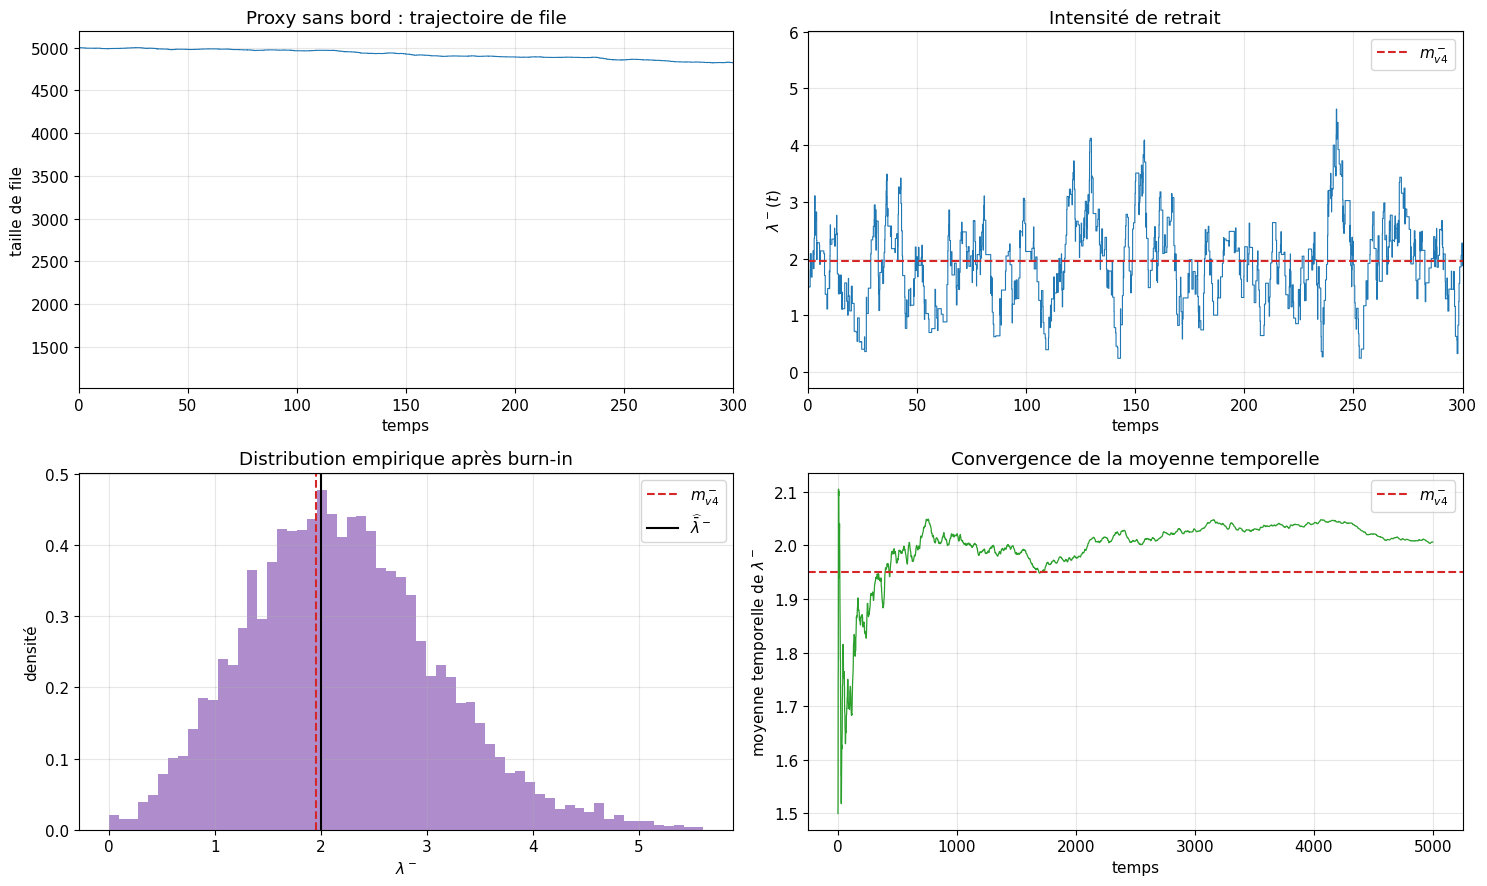

In [3]:
def moyenne_temporelle(times, values, horizon, burn_in=0.0):
    # Moyenne temporelle d'un processus en escalier observé aux temps d'événements.
    times = np.asarray(times)
    values = np.asarray(values)
    right_edges = np.r_[times[1:], horizon]
    left = np.maximum(times, burn_in)
    right = np.minimum(right_edges, horizon)
    weights = np.maximum(right - left, 0.0)
    if weights.sum() == 0:
        return np.nan
    return float(np.sum(values * weights) / weights.sum())


rng = np.random.default_rng(SEED)
T_long = 5_000.0
Q_STATIONNAIRE = 5_000
m_theo_v4 = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, "v4")

# Proxy sans bord : la file initiale est assez grande pour ne pas atteindre zéro.
res_long = simulate_hawkes_queue(
    q_init=Q_STATIONNAIRE,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=T_long,
    rng=rng,
    stop_at_zero=True,
    sign_convention="v4",
)

lambda_bar = moyenne_temporelle(
    res_long.times,
    res_long.lambda_minus_path,
    T_long,
    burn_in=T_long / 2,
)

# Vraie file de taille 50 : utile pour le temps d'atteinte, pas pour vérifier m^-.
res_queue_50 = simulate_hawkes_queue(
    q_init=50,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=T_long,
    rng=np.random.default_rng(SEED),
    stop_at_zero=True,
    sign_convention="v4",
)

print(f"m⁻ théorique v4 : {m_theo_v4:.4f}")
print(f"λ̄⁻ empirique, proxy sans bord : {lambda_bar:.4f}")
print(f"Écart relatif : {(lambda_bar / m_theo_v4 - 1):+.2%}")
print(f"File q_init=50 : hit_zero={res_queue_50.hit_zero}, T0={res_queue_50.hitting_time:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

removals = np.cumsum(res_long.event_types == -1)
axes[0, 0].step(res_long.times, res_long.queue_path, where="post", linewidth=0.8)
axes[0, 0].set_xlim(0, 300)
axes[0, 0].set_xlabel("temps")
axes[0, 0].set_ylabel("taille de file")
axes[0, 0].set_title("Proxy sans bord : trajectoire de file")

axes[0, 1].step(res_long.times, res_long.lambda_minus_path, where="post", linewidth=0.8)
axes[0, 1].axhline(m_theo_v4, color="tab:red", linestyle="--", label=r"$m^-_{v4}$")
axes[0, 1].set_xlim(0, 300)
axes[0, 1].set_xlabel("temps")
axes[0, 1].set_ylabel(r"$\lambda^-(t)$")
axes[0, 1].set_title("Intensité de retrait")
axes[0, 1].legend()

masque_stationnaire = res_long.times > T_long / 2
axes[1, 0].hist(res_long.lambda_minus_path[masque_stationnaire], bins=60, density=True, alpha=0.75, color="tab:purple")
axes[1, 0].axvline(m_theo_v4, color="tab:red", linestyle="--", label=r"$m^-_{v4}$")
axes[1, 0].axvline(lambda_bar, color="black", linewidth=1.5, label=r"$\widehat{\bar\lambda}^-$")
axes[1, 0].set_xlabel(r"$\lambda^-$")
axes[1, 0].set_ylabel("densité")
axes[1, 0].set_title("Distribution empirique après burn-in")
axes[1, 0].legend()

right_edges = np.r_[res_long.times[1:], T_long]
weights = np.maximum(right_edges - res_long.times, 0.0)
running_num = np.cumsum(res_long.lambda_minus_path * weights)
running_den = np.cumsum(weights)
running_mean = running_num / running_den
axes[1, 1].plot(res_long.times, running_mean, linewidth=0.9, color="tab:green")
axes[1, 1].axhline(m_theo_v4, color="tab:red", linestyle="--", label=r"$m^-_{v4}$")
axes[1, 1].set_xlabel("temps")
axes[1, 1].set_ylabel(r"moyenne temporelle de $\lambda^-$")
axes[1, 1].set_title("Convergence de la moyenne temporelle")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


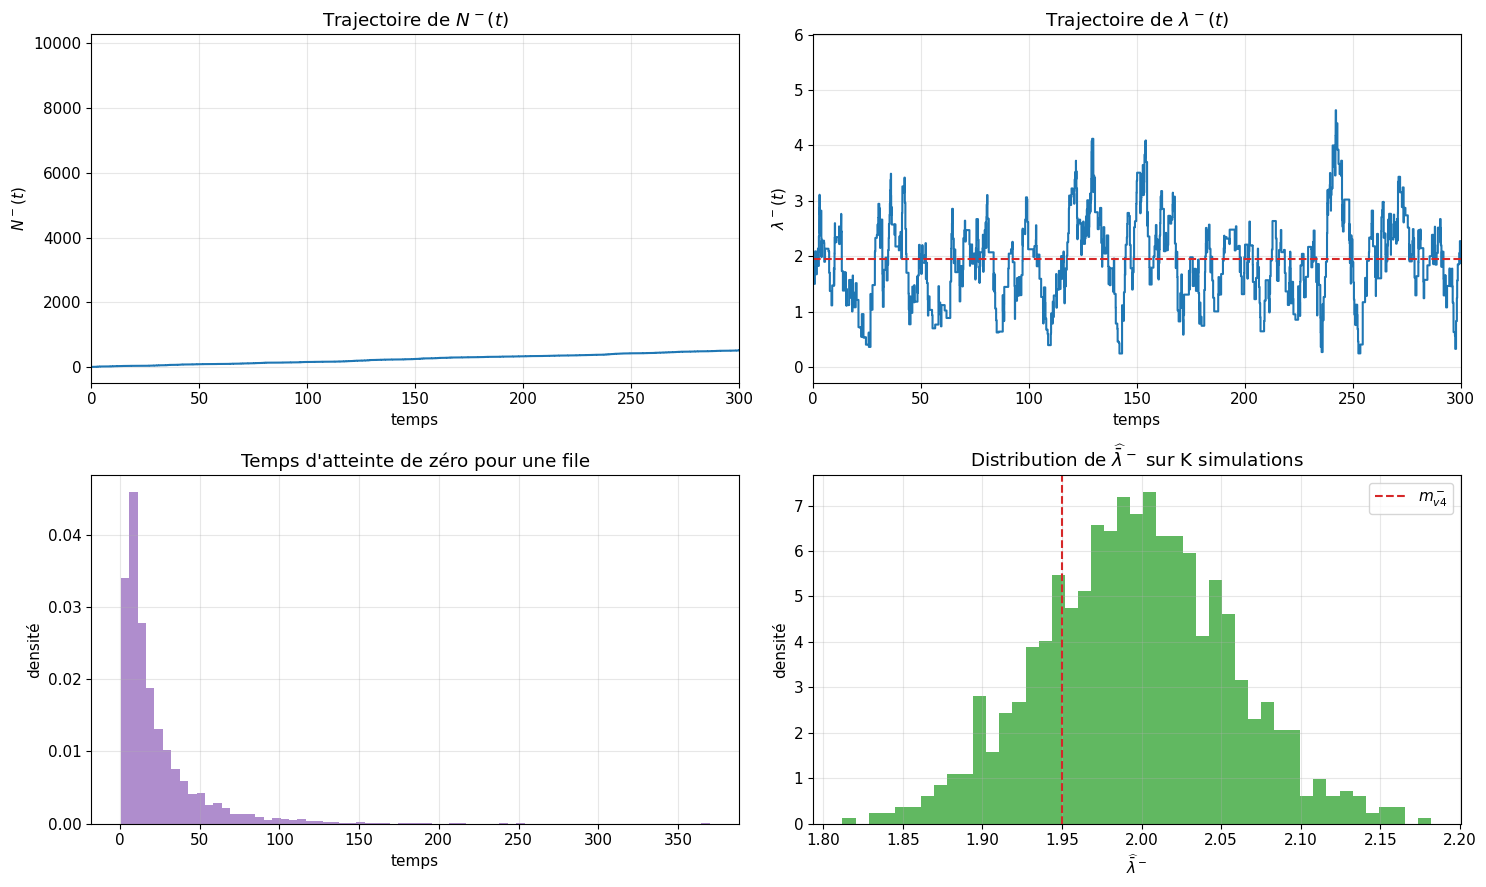

Moyenne des λ̄⁻ estimées : 1.9963
IC 95 % : [1.9926, 2.0000]
m⁻ théorique v4 : 1.9500


In [4]:
# Figure de synthèse en quatre panneaux, dans l'esprit de la Figure 4 du sujet.
K = 1_000
N_hit = 5_000
rng = np.random.default_rng(SEED)

lambda_moyennes = np.empty(K)
for k in range(K):
    r = simulate_hawkes_queue(
        q_init=Q_STATIONNAIRE,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=T_long,
        rng=rng,
        stop_at_zero=False,
        sign_convention="v4",
    )
    lambda_moyennes[k] = moyenne_temporelle(r.times, r.lambda_minus_path, T_long, burn_in=T_long / 2)

temps_hawkes_simple = np.empty(N_hit)
for k in range(N_hit):
    r = simulate_hawkes_queue(
        q_init=Q0,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=2_000.0,
        rng=rng,
        stop_at_zero=True,
        sign_convention="v4",
    )
    temps_hawkes_simple[k] = r.hitting_time

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].step(res_long.times, removals, where="post")
axes[0, 0].set_xlim(0, 300)
axes[0, 0].set_title(r"Trajectoire de $N^-(t)$")
axes[0, 0].set_xlabel("temps")
axes[0, 0].set_ylabel(r"$N^-(t)$")

axes[0, 1].step(res_long.times, res_long.lambda_minus_path, where="post")
axes[0, 1].axhline(m_theo_v4, color="tab:red", linestyle="--")
axes[0, 1].set_xlim(0, 300)
axes[0, 1].set_title(r"Trajectoire de $\lambda^-(t)$")
axes[0, 1].set_xlabel("temps")
axes[0, 1].set_ylabel(r"$\lambda^-(t)$")

axes[1, 0].hist(temps_hawkes_simple, bins=70, density=True, color="tab:purple", alpha=0.75)
axes[1, 0].set_title("Temps d'atteinte de zéro pour une file")
axes[1, 0].set_xlabel("temps")
axes[1, 0].set_ylabel("densité")

axes[1, 1].hist(lambda_moyennes, bins=45, density=True, color="tab:green", alpha=0.75)
axes[1, 1].axvline(m_theo_v4, color="tab:red", linestyle="--", label=r"$m^-_{v4}$")
axes[1, 1].set_title(r"Distribution de $\widehat{\bar\lambda}^-$ sur K simulations")
axes[1, 1].set_xlabel(r"$\widehat{\bar\lambda}^-$")
axes[1, 1].set_ylabel("densité")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

moy = np.nanmean(lambda_moyennes)
std = np.nanstd(lambda_moyennes, ddof=1)
ic = 1.96 * std / np.sqrt(np.sum(~np.isnan(lambda_moyennes)))
print(f"Moyenne des λ̄⁻ estimées : {moy:.4f}")
print(f"IC 95 % : [{moy - ic:.4f}, {moy + ic:.4f}]")
print(f"m⁻ théorique v4 : {m_theo_v4:.4f}")


**Interprétation.** Pour vérifier la formule théorique de $m^-$, on utilise la
simulation à grande file initiale comme approximation sans bord. La moyenne
empirique de $\lambda^-$ est alors proche de $m^-_{\mathrm{v4}}$, à l'erreur Monte
Carlo près. En revanche, une file de taille initiale modérée touche zéro ; dès
que la file est vide, les retraits sont impossibles, donc cette simulation ne
peut pas servir à estimer la moyenne stationnaire du Hawkes non contraint.


## Question 1.2.4.2 — Distribution des temps d'atteinte de zéro, file Hawkes seule

On simule au moins $5000$ temps d'atteinte pour une file Hawkes partant de
$q_{\mathrm{init}}=10$. On compare ensuite à une file de Poisson ayant le
même drift effectif, c'est-à-dire le même taux d'ajout $\mu^+$ et un taux
de retrait égal à $m^-_{\mathrm{v4}}$.


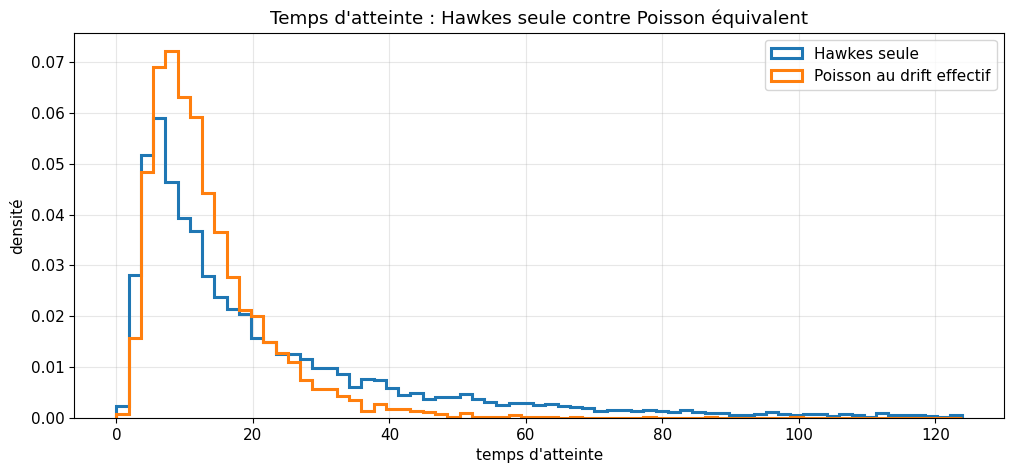

,modèle,moyenne,écart-type,n
0,Hawkes seule,22.822952,25.844070,5000
1,Poisson au drift effectif,13.283788,8.722286,5000


In [5]:
def simuler_temps_poisson_une_file(n_runs, q_init, lambda_plus, lambda_minus, rng, t_max=2_000.0):
    temps = np.empty(n_runs)
    for k in range(n_runs):
        q = q_init
        t = 0.0
        total = lambda_plus + lambda_minus
        while q > 0 and t < t_max:
            t += rng.exponential(1.0 / total)
            q += 1 if rng.random() < lambda_plus / total else -1
        temps[k] = t
    return temps


rng = np.random.default_rng(SEED)
N_sim = 5_000
lambda_eff = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, "v4")

# Si la cellule précédente n'a pas été exécutée, on recalcule les temps Hawkes.
if "temps_hawkes_simple" not in globals() or len(temps_hawkes_simple) < N_sim:
    temps_hawkes_simple = np.empty(N_sim)
    for k in range(N_sim):
        r = simulate_hawkes_queue(
            q_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True,
            sign_convention="v4",
        )
        temps_hawkes_simple[k] = r.hitting_time

temps_poisson_eff = simuler_temps_poisson_une_file(N_sim, Q0, MU_PLUS, lambda_eff, rng)

bins = np.linspace(0, np.quantile(np.r_[temps_hawkes_simple, temps_poisson_eff], 0.995), 70)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(temps_hawkes_simple, bins=bins, density=True, histtype="step", linewidth=2.2, label="Hawkes seule")
ax.hist(temps_poisson_eff, bins=bins, density=True, histtype="step", linewidth=2.2, label="Poisson au drift effectif")
ax.set_xlabel("temps d'atteinte")
ax.set_ylabel("densité")
ax.set_title("Temps d'atteinte : Hawkes seule contre Poisson équivalent")
ax.legend()
plt.show()

pd.DataFrame({
    "modèle": ["Hawkes seule", "Poisson au drift effectif"],
    "moyenne": [temps_hawkes_simple.mean(), temps_poisson_eff.mean()],
    "écart-type": [temps_hawkes_simple.std(ddof=1), temps_poisson_eff.std(ddof=1)],
    "n": [len(temps_hawkes_simple), len(temps_poisson_eff)],
})


**Conclusion.** Le modèle de Hawkes ne modifie pas seulement le drift moyen :
il introduit des grappes de retraits et donc une distribution de temps
d'atteinte plus asymétrique qu'un modèle de Poisson. La comparaison au Poisson
de taux $m^-_{\mathrm{v4}}$ sert ici de référence sans dépendance temporelle.


## Question 1.2.4.3 — Deux files Hawkes couplées

L'équation de couplage (3) rend les retraits des deux premières limites
dépendants. Dans la convention v4 utilisée ici, l'état de retrait de chaque
file reçoit une contribution négative après un ajout et positive après un
retrait. L'effet croisé transmet donc les vagues de retraits entre les deux
côtés du carnet.

On simule les deux files, puis on visualise les trajectoires, les intensités
et la corrélation empirique entre $Q_1$ et $Q_{-1}$.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


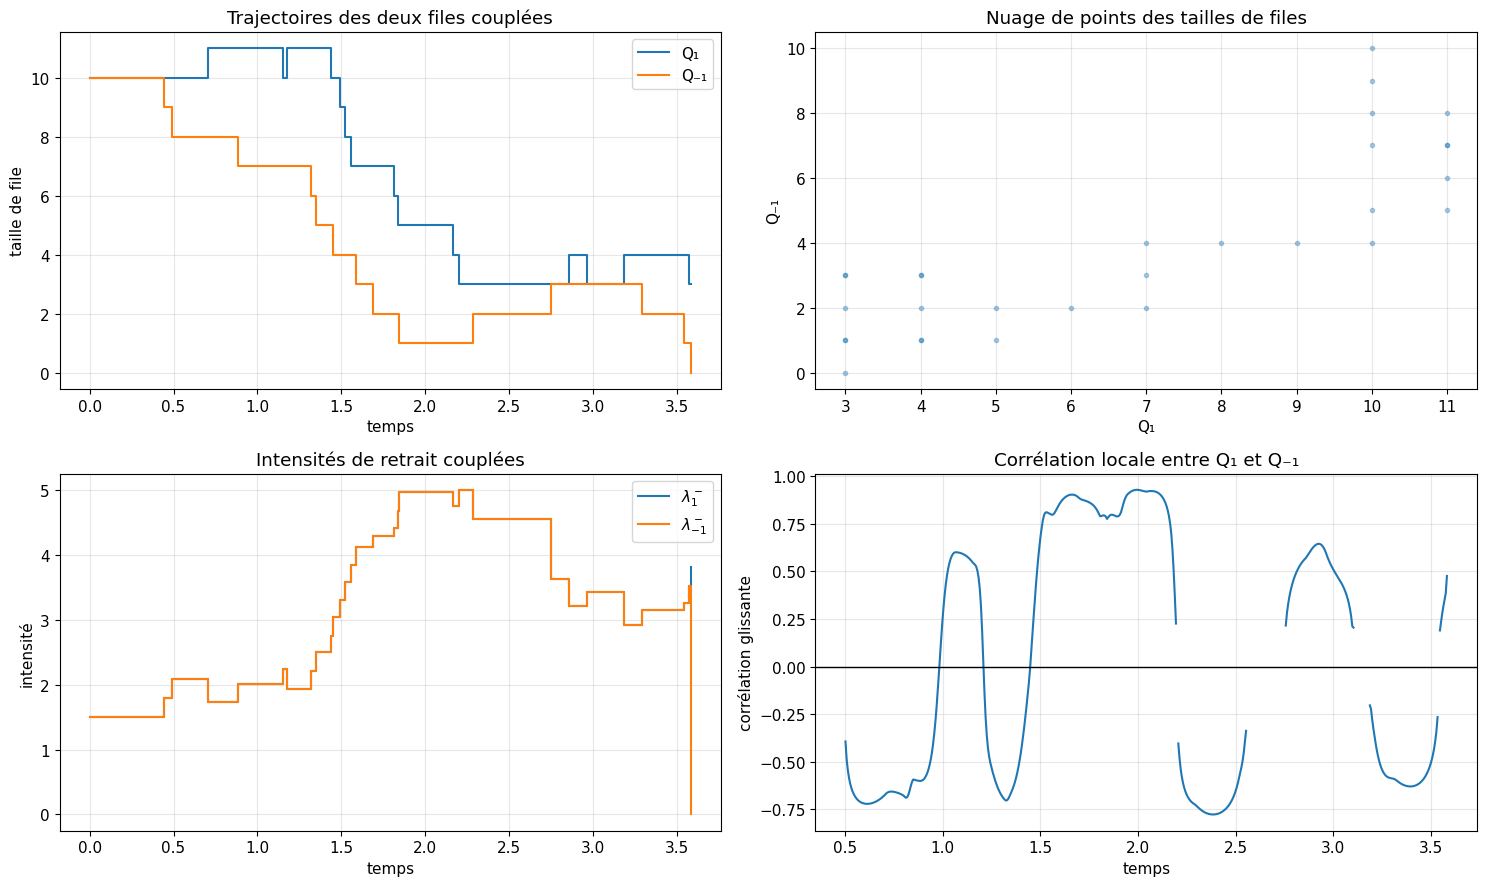

Corrélation globale interpolée : 0.863


In [6]:
rng = np.random.default_rng(SEED)
res_couple = simulate_coupled_hawkes(
    q1_init=Q0,
    q_neg1_init=Q0,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=300.0,
    rng=rng,
    stop_at_zero=True,
    sign_convention="v4",
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].step(res_couple.times, res_couple.q1_path, where="post", label="Q₁")
axes[0, 0].step(res_couple.times, res_couple.q_neg1_path, where="post", label="Q₋₁")
axes[0, 0].set_xlabel("temps")
axes[0, 0].set_ylabel("taille de file")
axes[0, 0].set_title("Trajectoires des deux files couplées")
axes[0, 0].legend()

axes[0, 1].plot(res_couple.q1_path, res_couple.q_neg1_path, ".", alpha=0.35)
axes[0, 1].set_xlabel("Q₁")
axes[0, 1].set_ylabel("Q₋₁")
axes[0, 1].set_title("Nuage de points des tailles de files")

axes[1, 0].step(res_couple.times, res_couple.lam_minus_1_path, where="post", label=r"$\lambda^-_1$")
axes[1, 0].step(res_couple.times, res_couple.lam_minus_neg1_path, where="post", label=r"$\lambda^-_{-1}$")
axes[1, 0].set_xlabel("temps")
axes[1, 0].set_ylabel("intensité")
axes[1, 0].set_title("Intensités de retrait couplées")
axes[1, 0].legend()

grille = np.linspace(res_couple.times[0], res_couple.times[-1], 600)
q1_interp = np.interp(grille, res_couple.times, res_couple.q1_path)
qn_interp = np.interp(grille, res_couple.times, res_couple.q_neg1_path)
fenetre = 60
corr_glissante = np.full(len(grille), np.nan)
for i in range(fenetre, len(grille)):
    corr_glissante[i] = np.corrcoef(q1_interp[i-fenetre:i], qn_interp[i-fenetre:i])[0, 1]

axes[1, 1].plot(grille, corr_glissante)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_xlabel("temps")
axes[1, 1].set_ylabel("corrélation glissante")
axes[1, 1].set_title("Corrélation locale entre Q₁ et Q₋₁")

plt.tight_layout()
plt.show()

print(f"Corrélation globale interpolée : {np.corrcoef(q1_interp, qn_interp)[0, 1]:.3f}")


**Interprétation.** Les intensités réagissent aux événements des deux files,
ce qui crée une dépendance visible dans les trajectoires. La corrélation
glissante n'est pas constante : elle dépend des épisodes de retraits groupés
et des périodes de reconstitution des files.


## Question 1.2.4.4 — Temps d'atteinte des deux files couplées

On simule le temps

$$
T_{\min}^{H,c}=\min(T_1^H,T_{-1}^H)
$$

pour le système Hawkes couplé, puis on le compare à la file Hawkes seule et
au modèle de Poisson indépendant de la section 1.2.3.


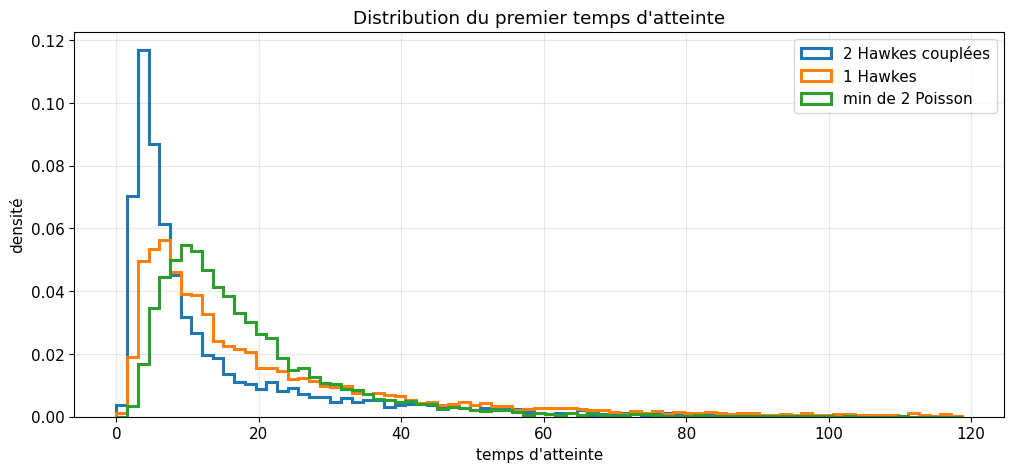

,modèle,moyenne,écart-type,n
0,2 Hawkes couplées,14.807327,18.358657,5000
1,1 Hawkes,22.822952,25.844070,5000
2,min de 2 Poisson,18.446196,13.775012,5000


In [7]:
rng = np.random.default_rng(SEED)
N_couple = 5_000

temps_hawkes_couple = np.empty(N_couple)
for k in range(N_couple):
    r = simulate_coupled_hawkes(
        q1_init=Q0,
        q_neg1_init=Q0,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=2_000.0,
        rng=rng,
        stop_at_zero=True,
        sign_convention="v4",
    )
    temps_hawkes_couple[k] = r.hitting_time

temps_poisson_min = np.empty(N_couple)
for k in range(N_couple):
    r = simulate_until_hit_zero(
        q1_init=Q0,
        q_neg1_init=Q0,
        lambda_plus=MU_PLUS,
        lambda_minus=MU_MINUS,
        rng=rng,
        record_path=False,
    )
    temps_poisson_min[k] = r.hitting_time

bins = np.linspace(0, np.quantile(np.r_[temps_hawkes_couple, temps_hawkes_simple[:N_couple], temps_poisson_min], 0.995), 80)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(temps_hawkes_couple, bins=bins, density=True, histtype="step", linewidth=2.2, label="2 Hawkes couplées")
ax.hist(temps_hawkes_simple[:N_couple], bins=bins, density=True, histtype="step", linewidth=2.2, label="1 Hawkes")
ax.hist(temps_poisson_min, bins=bins, density=True, histtype="step", linewidth=2.2, label="min de 2 Poisson")
ax.set_xlabel("temps d'atteinte")
ax.set_ylabel("densité")
ax.set_title("Distribution du premier temps d'atteinte")
ax.legend()
plt.show()

pd.DataFrame({
    "modèle": ["2 Hawkes couplées", "1 Hawkes", "min de 2 Poisson"],
    "moyenne": [temps_hawkes_couple.mean(), temps_hawkes_simple[:N_couple].mean(), temps_poisson_min.mean()],
    "écart-type": [temps_hawkes_couple.std(ddof=1), temps_hawkes_simple[:N_couple].std(ddof=1), temps_poisson_min.std(ddof=1)],
    "n": [N_couple, N_couple, N_couple],
})


**Conclusion.** Le couplage modifie à la fois le niveau moyen et la forme de
la distribution. En particulier, des épisodes de retraits mutuellement
excités peuvent produire des atteintes de zéro plus rapides que dans le cas
indépendant.


## Question 1.2.4.5 — Comparaison des quatre cas en convention v4

Le sujet annonce l'ordre attendu

$$
\mathbb{E}\!\left[T_{\text{2 Hawkes couplees}}\right]
<\mathbb{E}\!\left[T_{\text{1 Hawkes}}\right]
<\mathbb{E}\!\left[T_{\min,\text{2 Poisson}}\right]
<\mathbb{E}\!\left[T_{\text{1 Poisson}}\right].
$$

Dans ce notebook, on ne teste que la convention corrigée v4 :

$$
\lambda^- = \mu^- - \phi \ast dN^+ + \phi \ast dN^-.
$$

La cellule suivante calcule les quatre distributions avec au moins $2000$
trajectoires par modèle. Si l'ordre numérique diffère de l'ordre attendu par
l'énoncé, on l'interprète comme une conséquence de la convention v4 et des
contraintes de bord des files, sans introduire d'autre convention de signes.


In [8]:
def simuler_temps_poisson_min(n_runs, q_init, lambda_plus, lambda_minus, rng):
    temps = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_until_hit_zero(
            q1_init=q_init,
            q_neg1_init=q_init,
            lambda_plus=lambda_plus,
            lambda_minus=lambda_minus,
            rng=rng,
            record_path=False,
        )
        temps[k] = r.hitting_time
    return temps


def resume(arr):
    arr = np.asarray(arr)
    m = arr.mean()
    s = arr.std(ddof=1)
    h = 1.96 * s / np.sqrt(len(arr))
    return m, s, m - h, m + h, len(arr)


def comparaison_quatre_modeles_v4(n_runs=2_000, seed=42):
    rng = np.random.default_rng(seed)

    single_poisson = simuler_temps_poisson_une_file(n_runs, Q0, MU_PLUS, MU_MINUS, rng)
    two_poisson = simuler_temps_poisson_min(n_runs, Q0, MU_PLUS, MU_MINUS, rng)

    single_hawkes = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_hawkes_queue(
            q_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True,
            sign_convention="v4",
        )
        single_hawkes[k] = r.hitting_time

    two_hawkes = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_coupled_hawkes(
            q1_init=Q0,
            q_neg1_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True,
            sign_convention="v4",
        )
        two_hawkes[k] = r.hitting_time

    donnees = {
        "1 Poisson": single_poisson,
        "min 2 Poisson": two_poisson,
        "1 Hawkes": single_hawkes,
        "2 Hawkes couplées": two_hawkes,
    }
    lignes = []
    for nom, arr in donnees.items():
        m, s, bas, haut, n = resume(arr)
        lignes.append({
            "modèle": nom,
            "E[T]": m,
            "std": s,
            "IC 95% bas": bas,
            "IC 95% haut": haut,
            "n_runs": n,
        })
    return donnees, pd.DataFrame(lignes)


donnees_v4, table_comparaison = comparaison_quatre_modeles_v4(n_runs=2_000, seed=SEED)
table_comparaison


,modèle,E[T],std,IC 95% bas,IC 95% haut,n_runs
0,1 Poisson,33.006574,31.118112,31.642763,34.370385,2000
1,min 2 Poisson,18.777855,13.357535,18.192436,19.363275,2000
2,1 Hawkes,22.566062,25.205461,21.461384,23.670740,2000
3,2 Hawkes couplées,14.679343,17.540529,13.910596,15.448091,2000


Ordre attendu vérifié en convention v4 ? False
  2 Hawkes couplées    : 14.6793
  1 Hawkes             : 22.5661
  min 2 Poisson        : 18.7779
  1 Poisson            : 33.0066


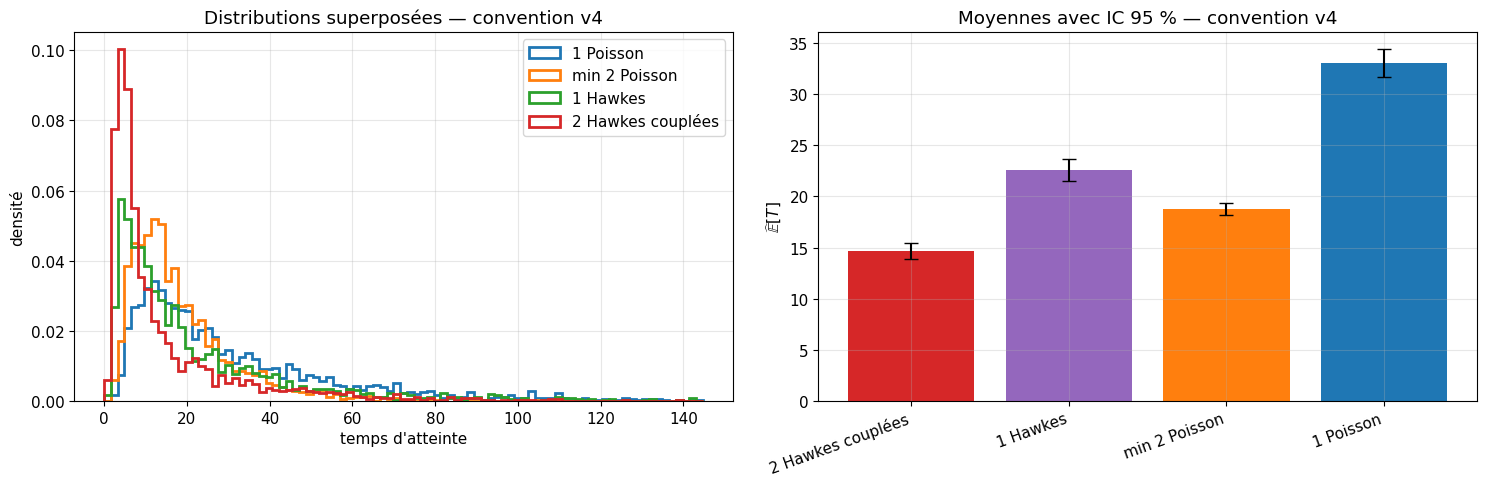

In [9]:
ordre_attendu = ["2 Hawkes couplées", "1 Hawkes", "min 2 Poisson", "1 Poisson"]

table_ord = table_comparaison.set_index("modèle").loc[ordre_attendu]
moyennes = table_ord["E[T]"].values
ordre_verifie = bool(np.all(np.diff(moyennes) > 0))

print(f"Ordre attendu vérifié en convention v4 ? {ordre_verifie}")
for nom, val in zip(ordre_attendu, moyennes):
    print(f"  {nom:20s} : {val:.4f}")

valeurs = np.concatenate(list(donnees_v4.values()))
bins = np.linspace(0, np.quantile(valeurs, 0.995), 90)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for nom in ordre_attendu[::-1]:
    axes[0].hist(donnees_v4[nom], bins=bins, density=True, histtype="step", linewidth=2, label=nom)
axes[0].set_xlabel("temps d'atteinte")
axes[0].set_ylabel("densité")
axes[0].set_title("Distributions superposées — convention v4")
axes[0].legend()

err = np.vstack([
    moyennes - table_ord["IC 95% bas"].values,
    table_ord["IC 95% haut"].values - moyennes,
])
axes[1].bar(range(len(ordre_attendu)), moyennes, yerr=err, capsize=5, color=["tab:red", "tab:purple", "tab:orange", "tab:blue"])
axes[1].set_xticks(range(len(ordre_attendu)))
axes[1].set_xticklabels(ordre_attendu, rotation=20, ha="right")
axes[1].set_ylabel(r"$\widehat{\mathbb{E}}[T]$")
axes[1].set_title("Moyennes avec IC 95 % — convention v4")

plt.tight_layout()
plt.show()


**Discussion.** En convention v4, un ajout rend la file plus persistante : il
réduit temporairement le taux de retrait. Un retrait, au contraire, signale
une consommation en cours et augmente temporairement le taux de retrait. Le
modèle combine donc une inertie après les ajouts et une auto-excitation après
les retraits.

L'ordre attendu par l'énoncé doit être lu avec prudence : il dépend de la
convention de signes et du fait que les files sont arrêtées au bord zéro. Ici,
on conserve strictement la convention v4. Si le tableau ne reproduit pas
exactement l'ordre annoncé, ce n'est pas corrigé en changeant les signes ; on
le reporte comme un effet numérique du modèle v4 effectivement simulé.
